# CNN Simples

A ideia agora é remover a Wavelet, o ROI e o CBAM da CNN para validar qual será o resultado de uma CNN convencional simples recebendo a imagem mamográfica inteira.

## Preparação dos Dados: CLASSIFICAÇÃO + 5-FOLD + CROSS-VALIDATION

- Classificando as imagnes do Dataset mini-mias

- Carregando dataset para CNN aplicando Data Augmentation (aumento de dados)
    - Efetuado ainda mais variações nas imagens (data augmentation) para conseguir aumentar o dataset.

### ESTRUTURA FINAL:

1. Configuração da semente
2. Definição dos caminhos
3. Funções auxiliares (CLAHE, visualização)
4. Transforms (treino e teste)
5. Processamento das imagens (sem ROI)
6. Criação do dataset e divisão com Cross-Validation

```python
    dataset_cv = datasets.ImageFolder("dataset_cv", transform=test_transform)
    targets = dataset_cv.targets
    indices = np.arange(len(targets))
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
```

Semente 42 configurada com sucesso!
Total de imagens encontradas: 322
Dataset pronto para CV: 320 imagens.

Mostrando exemplos (SEM ROI)...


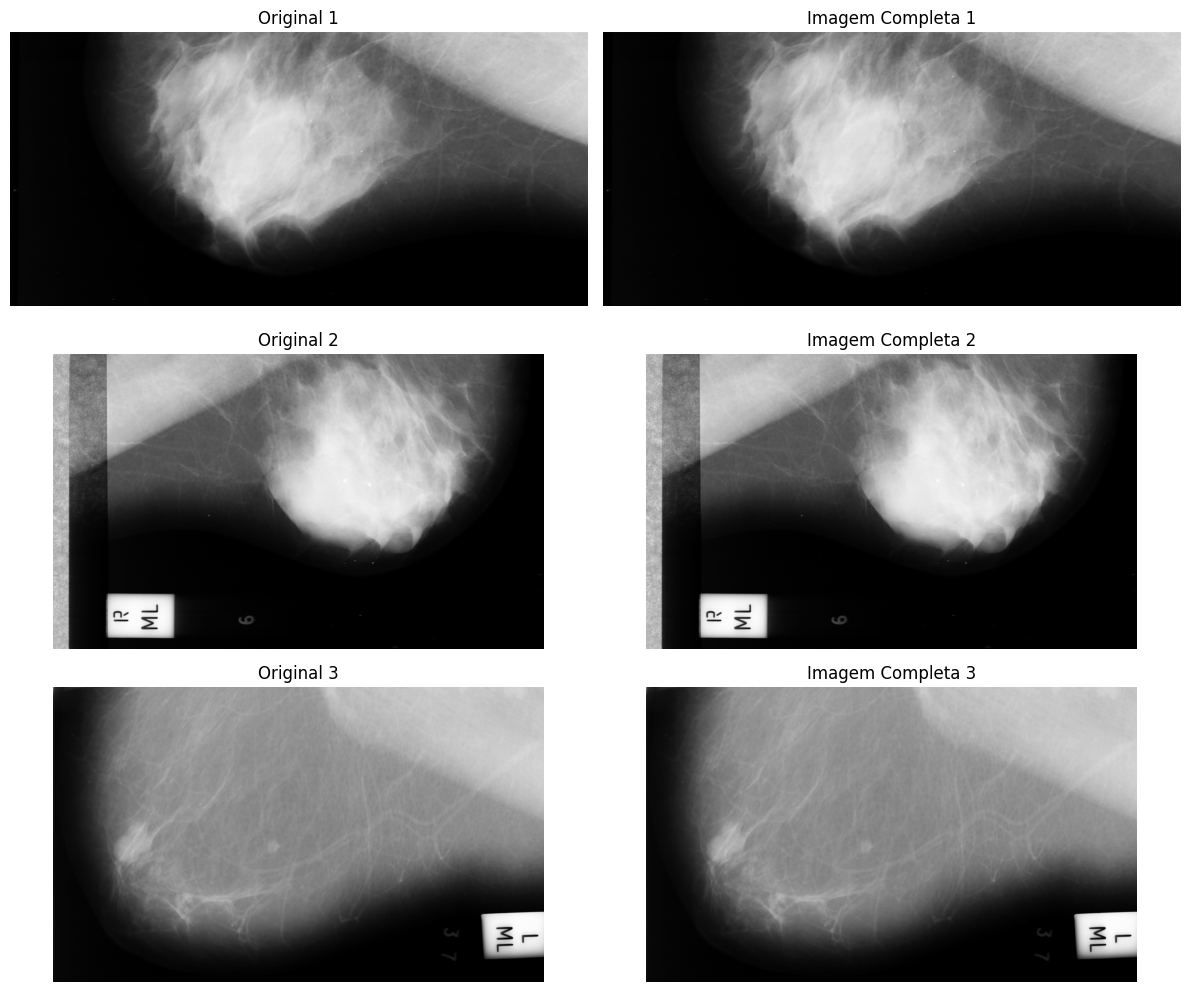


PIPELINE DE DADOS PARA CROSS-VALIDATION VALIDADO (SEM ROI)!


In [1]:
import os
import torch
import random
import shutil
from PyPDF2 import PdfReader
import cv2
import numpy as np
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# === CONFIGURAR SEED =====
def configurar_semente(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Semente {seed} configurada com sucesso!")

configurar_semente(42)
# ============================

# ================================
# CONFIG
# ================================
PASTA_MIAs = "dataset-mias"
OUTPUT_DATASET = "dataset"
PDF_PATH = os.path.join(PASTA_MIAs, "00README.pdf")

# ================================
# 1. PEGAR IMAGENS
# ================================
todas_imagens = sorted([
    f for f in os.listdir(PASTA_MIAs)
    if f.endswith(".pgm")
])

print(f"Total de imagens encontradas: {len(todas_imagens)}")

# ================================
# 2. LER PDF (APENAS CLASSES)
# ================================
reader = PdfReader(PDF_PATH)

texto_total = ""
for pagina in reader.pages:
    txt = pagina.extract_text()
    if txt:
        texto_total += txt + "\n"

linhas = texto_total.split("\n")

mapa_classes = {}

for linha in linhas:
    linha = linha.strip()

    if linha.startswith("mdb"):
        partes = linha.split()

        if len(partes) >= 3:
            nome = partes[0] + ".pgm"
            classe = partes[2]
            mapa_classes[nome] = classe

# ================================
# 3. CLASSIFICAÇÃO
# ================================
com_nodulo = []
sem_nodulo = []

for nome in todas_imagens:
    classe = mapa_classes.get(nome, None)

    if classe is None:
        continue
    elif classe == "NORM":
        sem_nodulo.append(nome)
    else:
        com_nodulo.append(nome)

# ================================
# 4. LIMPAR E PREPARAR PASTAS
# ================================
shutil.rmtree(OUTPUT_DATASET, ignore_errors=True)
shutil.rmtree("dataset_cv", ignore_errors=True)

os.makedirs("dataset_cv/com_nodulo", exist_ok=True)
os.makedirs("dataset_cv/sem_nodulo", exist_ok=True)

# ===========================================
# 5. CLAHE + TRANSFORMS
# ===========================================
class ApplyCLAHE:
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __call__(self, img):
        img_np = np.array(img)

        if img_np.ndim == 3:
            img_np = img_np[..., 0]

        img_np = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        return Image.fromarray(self.clahe.apply(img_np))

# Transform de TESTE
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    ApplyCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# Transform de TREINO
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    ApplyCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# ================================================================
# 6. PROCESSAMENTO PARA CROSS-VALIDATION (SEM ROI)
# ================================================================
def processar_para_cv(lista_com, lista_sem):
    exemplos_para_plot = []
    
    def salvar(lista, subpasta):
        for nome in lista:
            img = cv2.imread(os.path.join(PASTA_MIAs, nome), cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                continue

            destino = os.path.join(f"dataset_cv/{subpasta}", nome)

            # USANDO IMAGEM COMPLETA (SEM ROI)
            cv2.imwrite(destino, img)

            # exemplos para visualização
            if len(exemplos_para_plot) < 6:
                exemplos_para_plot.append((img, img))

    salvar(lista_com, "com_nodulo")
    salvar(lista_sem, "sem_nodulo")

    return exemplos_para_plot

# Executa processamento
exemplos_visualizacao = processar_para_cv(com_nodulo, sem_nodulo)

# Dataset final
dataset_cv = datasets.ImageFolder("dataset_cv", transform=test_transform)
print(f"Dataset pronto para CV: {len(dataset_cv)} imagens.")

targets = dataset_cv.targets
indices = np.arange(len(targets))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ================================
# 7. VISUALIZAÇÃO (SEM ROI)
# ================================
def mostrar_exemplos(exemplos):
    if not exemplos:
        print("Nenhum exemplo para mostrar.")
        return

    plt.figure(figsize=(12, 10))
    
    for i, (orig, proc) in enumerate(exemplos):
        if i >= 3:
            break
        
        # Original
        plt.subplot(3, 2, 2*i + 1)
        plt.imshow(orig, cmap='gray')
        plt.title(f"Original {i+1}")
        plt.axis('off')

        # Processada (igual à original)
        plt.subplot(3, 2, 2*i + 2)
        plt.imshow(proc, cmap='gray')
        plt.title(f"Imagem Completa {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("\nMostrando exemplos (SEM ROI)...")
mostrar_exemplos(exemplos_visualizacao)

print("\nPIPELINE DE DADOS PARA CROSS-VALIDATION VALIDADO (SEM ROI)!")

## Modelo Baseline - CNN Convencional

<img src="img/baseline-semCBAM-modelo23.png" width="800" title="Dica de ferramenta">

In [2]:
"""MODELO SEM WAVELET, SEM CBAM E SEM ROI - FOCO APENAS EM CONVOLUÇÕES"""
import torch.nn as nn

class CNN_Simples(nn.Module):
    """
    Versão puramente convolucional.
    """
    def __init__(self, num_classes=2):
        super().__init__()

        # Camada inicial
        self.input_layer = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.features = nn.Sequential(
            # Bloco 1 
            nn.MaxPool2d(kernel_size=2, stride=2), # Redução espacial 1/2 (128x128)

            # Bloco 2 
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Redução espacial 1/4 (64x64)

            # Bloco 3 
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Redução espacial 1/8 (32x32)
            
            # Bloco 4 (Mantendo compatibilidade de canais)
            nn.Conv2d(128, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.input_layer(x)
        x = self.features(x)
        x = self.classifier(x)
        return x

## Treino + Avaliação do Modelo

Para avaliar o desempenho da Wavelet CNN no diagnóstico de mamografias, utilizamos a técnica de Validação Cruzada Estratificada em 5 Partes (Stratified 5-Fold Cross-Validation).

### Processo de Treino e Validação:

- Divisão em 5 Grupos: O conjunto de 320 imagens foi dividido em 5 partes iguais.

- Rodízio de Testes: O modelo foi treinado 5 vezes. Em cada vez, ele usou 4 partes para aprender e "escondeu" 1 parte para testar sua eficiência. Assim, todas as imagens foram testadas pelo menos uma vez.

- Estratificação: Garantimos que cada um dos 5 grupos tivesse a mesma proporção de casos "Normais" e "Com Nódulo", evitando que o modelo ficasse viciado em apenas uma classe.

### Garantia de replicação do resultado

- Semente Fixa (Seed 42): Usada para que os resultados sejam sempre os mesmos ao rodar o código, permitindo a conferência dos dados.

- Aumento de Dados (Data Augmentation): Aplicamos rotações e cortes aleatórios apenas no treino. As imagens de teste permaneceram originais para simular um diagnóstico real.

- Métricas de Desempenho: Além da Acurácia, calculamos a Média e o Desvio Padrão do F1-Score e do AUC, garantindo que o modelo é estável e confiável.

Treinando no dispositivo: cuda

--- FOLD 1/5 ---


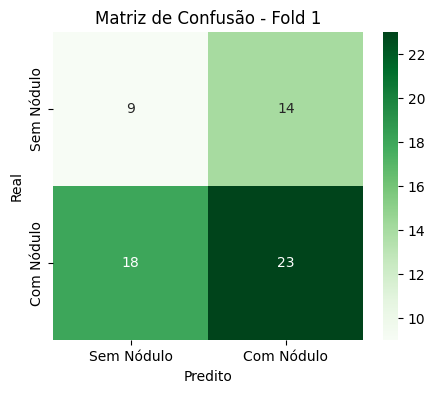

Fold 1 finalizado. Acc: 50.00% | F1: 0.5072

--- FOLD 2/5 ---


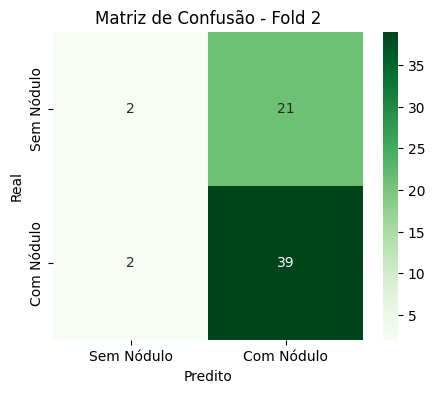

Fold 2 finalizado. Acc: 64.06% | F1: 0.5480

--- FOLD 3/5 ---


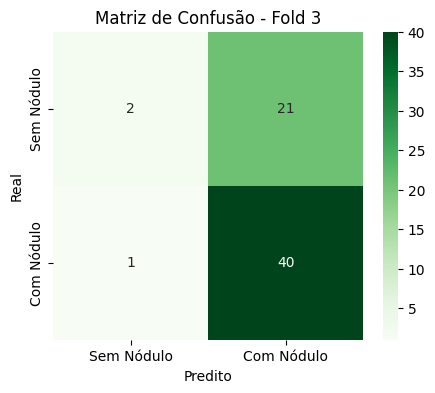

Fold 3 finalizado. Acc: 65.62% | F1: 0.5577

--- FOLD 4/5 ---


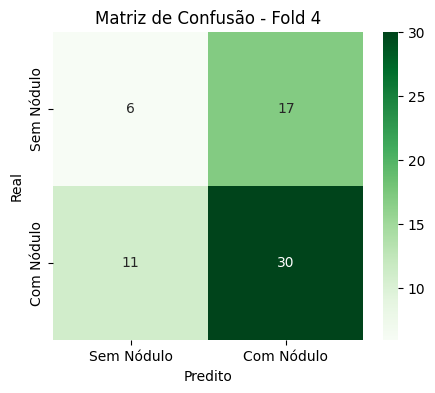

Fold 4 finalizado. Acc: 56.25% | F1: 0.5446

--- FOLD 5/5 ---


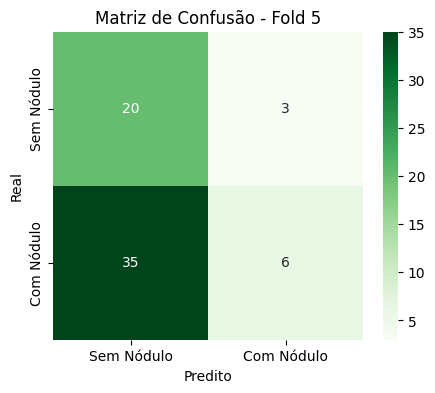

Fold 5 finalizado. Acc: 40.62% | F1: 0.3380

Média Final Acc: 55.31% ± 9.25
Média Final F1:  0.4991 ± 0.0823
Média Final AUC: 0.4923 ± 0.0217

==================== ANÁLISE FINAL CONSOLIDADA ====================


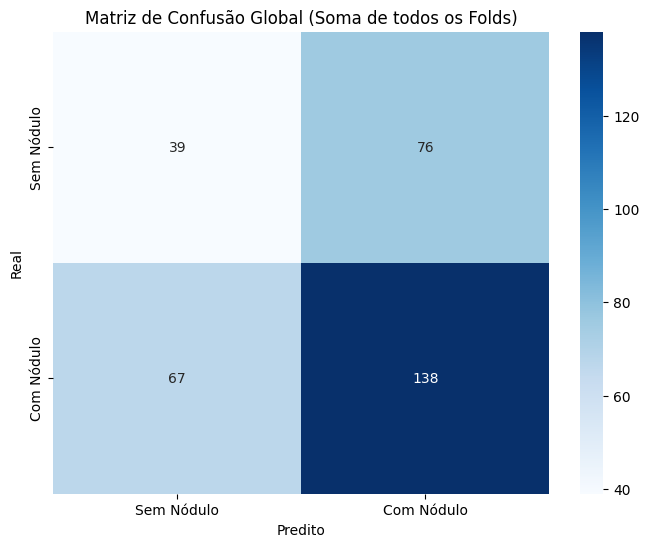

              precision    recall  f1-score   support

  Sem Nódulo       0.37      0.34      0.35       115
  Com Nódulo       0.64      0.67      0.66       205

    accuracy                           0.55       320
   macro avg       0.51      0.51      0.51       320
weighted avg       0.55      0.55      0.55       320



In [3]:
import torch
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

# 1. DEFINIR O DISPOSITIVO (GPU) 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando no dispositivo: {device}")

acc_folds, f1_folds, auc_folds = [], [], []

## Listas para acumular o resultado GLOBAL
todas_labels_global = []
todas_predicoes_global = []

for fold, (train_idx, val_idx) in enumerate(skf.split(indices, targets), 1):
    print(f"\n--- FOLD {fold}/5 ---")
    
    # Criar Subsets
    train_sub = torch.utils.data.Subset(dataset_cv, train_idx)
    val_sub = torch.utils.data.Subset(dataset_cv, val_idx)

    # No treino, usamos aumento de dados (train_transform)
    train_sub.dataset.transform = train_transform
    loader_train = DataLoader(train_sub, batch_size=32, shuffle=True)

    # Na validação (teste do fold), usamos a imagem limpa (test_transform)
    val_sub.dataset.transform = test_transform
    loader_val = DataLoader(val_sub, batch_size=32, shuffle=False)
    # =============================================

    # Inicializa o modelo na GPU
    model = CNN_Simples().to(device) 
    optimizer = optim.Adam(model.parameters(), lr=3e-4)
    criterion = nn.CrossEntropyLoss()

    # LOOP DE TREINO (50 épocas)
    for epoch in range(50):
        model.train()
        for imagens, labels in loader_train:
            imagens, labels = imagens.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imagens)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # BLOCO DE TESTE DO FOLD
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for imagens, labels in loader_val:
            imagens, labels = imagens.to(device), labels.to(device)
            outputs = model(imagens)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(probs.cpu().numpy()[:, 1])
    
    # === MATRIZ DE CONFUSÃO DO FOLD ATUAL ===
    plt.figure(figsize=(5, 4))
    cm_fold = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm_fold, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Sem Nódulo', 'Com Nódulo'], 
                yticklabels=['Sem Nódulo', 'Com Nódulo'])
    plt.title(f'Matriz de Confusão - Fold {fold}')
    plt.ylabel('Real')
    plt.xlabel('Predito')
    plt.show()

    # Acumula para o Global
    todas_labels_global.extend(y_true)
    todas_predicoes_global.extend(y_pred)

    # Cálculo das métricas
    acc_folds.append(accuracy_score(y_true, y_pred))
    f1_folds.append(f1_score(y_true, y_pred, average='weighted'))
    auc_folds.append(roc_auc_score(y_true, y_probs))
    
    print(f"Fold {fold} finalizado. Acc: {acc_folds[-1]*100:.2f}% | F1: {f1_folds[-1]:.4f}")

# RESULTADOS FINAIS
print("\n" + "="*40)
print(f"Média Final Acc: {np.mean(acc_folds)*100:.2f}% ± {np.std(acc_folds)*100:.2f}")
print(f"Média Final F1:  {np.mean(f1_folds):.4f} ± {np.std(f1_folds):.4f}")
print(f"Média Final AUC: {np.mean(auc_folds):.4f} ± {np.std(auc_folds):.4f}")
print("="*40)

# === APÓS O LOOP DE TODOS OS FOLDS: MATRIZ GLOBAL ===
print("\n" + "="*20 + " ANÁLISE FINAL CONSOLIDADA " + "="*20)

plt.figure(figsize=(8, 6))
cm_global = confusion_matrix(todas_labels_global, todas_predicoes_global)
sns.heatmap(cm_global, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem Nódulo', 'Com Nódulo'], 
            yticklabels=['Sem Nódulo', 'Com Nódulo'])
plt.title('Matriz de Confusão Global (Soma de todos os Folds)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

# Relatório estatístico completo
print(classification_report(todas_labels_global, todas_predicoes_global, 
                            target_names=['Sem Nódulo', 'Com Nódulo']))